## Import Library and Variables

In [1]:
import os
from pathlib import Path

while not Path("configs/config.yaml").exists():
  parent = os.path.dirname(os.getcwd())
  if parent == os.getcwd():
    raise RuntimeError("Root project tidak ketemu.")
  os.chdir(parent)

import yaml
import tensorflow as tf

CONFIG   = yaml.safe_load(Path("configs/config.yaml").read_text())
SPLITS   = Path(CONFIG["data"]["splits_dir"])
CLASSES  = CONFIG["data"]["classes"]
IMG_SIZE = CONFIG["image"]["size"]
BATCH    = CONFIG["train"]["batch_size"]
SEED     = CONFIG["seed"]

print("TF version:", tf.__version__)

TF version: 2.21.0


## Load Data

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  SPLITS / "train",
  labels="inferred",
  label_mode="int",
  class_names=CLASSES,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH,
  shuffle=True,
  seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  SPLITS / "val",
  labels="inferred", label_mode="int", class_names=CLASSES,
  image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
  SPLITS / "test",
  labels="inferred", label_mode="int", class_names=CLASSES,
  image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, shuffle=False,
)

print(train_ds.class_names)

Found 3062 files belonging to 4 classes.
Found 381 files belonging to 4 classes.
Found 386 files belonging to 4 classes.
['angry', 'happy', 'relaxed', 'sad']


## Train Model

In [3]:
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [4]:
num_classes = len(CLASSES)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes)(x)                      
model_mnet = tf.keras.Model(inputs, outputs)

model_mnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
model_mnet.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["train"]["lr"]),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

callbacks = [
  tf.keras.callbacks.EarlyStopping(
    patience=CONFIG["train"]["early_stopping_patience"],
    restore_best_weights=True),
  tf.keras.callbacks.ModelCheckpoint(
    "models/mobilenet.keras", save_best_only=True),
]

history = model_mnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["train"]["epochs"],
    callbacks=callbacks,
)

Epoch 1/30


c:\Dev\Project UAS ML Prak\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4801 - loss: 1.2318 - val_accuracy: 0.6509 - val_loss: 0.8890
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 912ms/step - accuracy: 0.6244 - loss: 0.9275 - val_accuracy: 0.7087 - val_loss: 0.7961
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 79s 823ms/step - accuracy: 0.6731 - loss: 0.8239 - val_accuracy: 0.7165 - val_loss: 0.7573
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6819 - loss: 0.7813 - val_accuracy: 0.7165 - val_loss: 0.7240
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 89s 924ms/step - accuracy: 0.7211 - loss: 0.7203 - val_accuracy: 0.7323 - val_loss: 0.7140
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 855ms/step - accuracy: 0.7195 - loss: 0.7056 - val_accuracy: 0.7428 - val_loss: 0.6924
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 845ms/step - accuracy: 0.7296 - loss: 0.6809 - val_accuracy: 0.7402 - val_loss: 0.7004
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 860ms/step - accuracy: 0.7440 - loss: 0.6614 - val_accuracy: 0.7428 - 

## Fine-Tuning

In [6]:
base_model.trainable = True

FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model_mnet.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["train"]["lr"] / 10),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

total_epochs = CONFIG["train"]["epochs"] + 10
history_ft = model_mnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history.history["loss"]),
    callbacks=callbacks,
)

Epoch 20/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.7289 - loss: 0.6862 - val_accuracy: 0.7244 - val_loss: 0.7489
Epoch 21/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8560 - loss: 0.3808 - val_accuracy: 0.7900 - val_loss: 0.5643
Epoch 22/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9095 - loss: 0.2472 - val_accuracy: 0.7979 - val_loss: 0.6695
Epoch 23/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9409 - loss: 0.1808 - val_accuracy: 0.7612 - val_loss: 0.8850
Epoch 24/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9562 - loss: 0.1257 - val_accuracy: 0.8136 - val_loss: 0.6409
Epoch 25/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9624 - loss: 0.1130 - val_accuracy: 0.8399 - val_loss: 0.5601
Epoch 26/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9749 - loss: 0.0798 - val_accuracy: 0.8346 - val_loss: 0.6141
Epoch 27/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9807 - loss: 0.0611 - val_accuracy: 0.

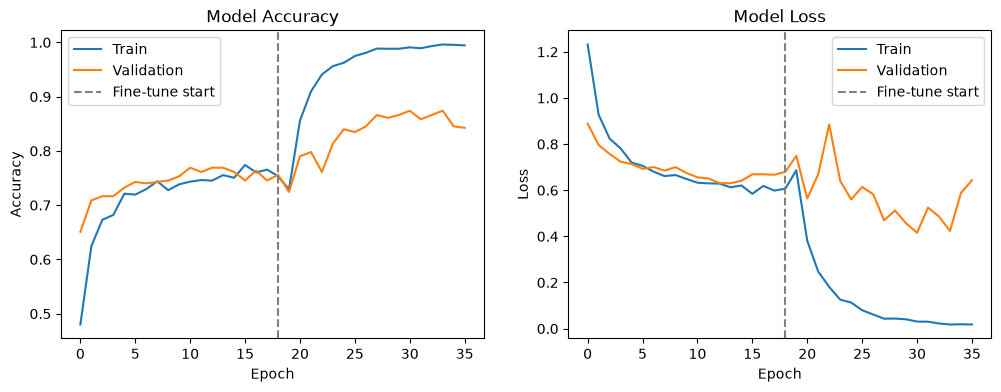

In [7]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history.history["loss"] + history_ft.history["loss"]
val_loss = history.history["val_loss"] + history_ft.history["val_loss"]
ft_start = len(history.history["loss"])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train"); plt.plot(val_acc, label="Validation")
plt.axvline(ft_start - 1, color="gray", ls="--", label="Fine-tune start")
plt.title("Model Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train"); plt.plot(val_loss, label="Validation")
plt.axvline(ft_start - 1, color="gray", ls="--", label="Fine-tune start")
plt.title("Model Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.savefig("reports/figures/mobilenet_training.png", dpi=120, bbox_inches="tight")
plt.show()

## Prediction Model

In [8]:
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_logits = model_mnet.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

print("jumlah test:", len(y_true))
print("contoh y_true:", y_true[:10])
print("contoh y_pred:", y_pred[:10])

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 677ms/step
jumlah test: 386
contoh y_true: [0 0 0 0 0 0 0 0 0 0]
contoh y_pred: [1 0 0 1 0 0 0 0 0 0]


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

              precision    recall  f1-score   support

       angry      0.888     0.859     0.873        92
       happy      0.919     0.919     0.919        99
     relaxed      0.899     0.908     0.904        98
         sad      0.909     0.928     0.918        97

    accuracy                          0.904       386
   macro avg      0.904     0.903     0.904       386
weighted avg      0.904     0.904     0.904       386



## Metrik Evaluasi

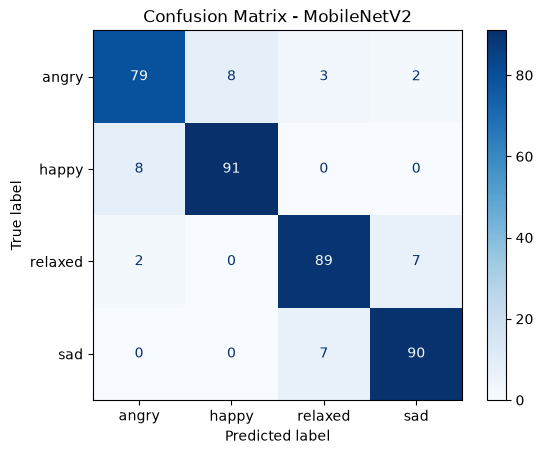

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=CLASSES, cmap="Blues", colorbar=True
)
plt.title("Confusion Matrix - MobileNetV2")
plt.savefig("reports/figures/mobilenet_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

## Export ke TFLite

In [11]:
export_model = tf.keras.Sequential([
    model_mnet,
    tf.keras.layers.Softmax(),
])
export_model.build((None, IMG_SIZE, IMG_SIZE, 3))

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

Path("models/model_final.tflite").write_bytes(tflite_model)

Path("models/labels.txt").write_text("\n".join(CLASSES))
print("Tersimpan: models/model_final.tflite ({:.2f} MB)".format(len(tflite_model) / 1e6))
print("Labels:", CLASSES)

INFO:tensorflow:Assets written to: C:\Users\asusA\AppData\Local\Temp\tmp0a_s0yme\assets


INFO:tensorflow:Assets written to: C:\Users\asusA\AppData\Local\Temp\tmp0a_s0yme\assets


Saved artifact at 'C:\Users\asusA\AppData\Local\Temp\tmp0a_s0yme'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_166')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2871746031120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871746035536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871746031312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871746032080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871746021520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871747346896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871747348816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871747349008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871747347856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2871747346704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2